# The Overnight GRF Pilot — a guided tour

**What this notebook is.** On the night of 2026-07-02 → 03 we ran a pre-registered
"kill test" for a research direction: *auditing the correctness of steered diffusion
samplers on problems where the right answer is known exactly.* This notebook walks
through what we built, why, and what came out — assuming familiarity with Bayesian
inference and Wiener filtering, but **not** with diffusion samplers. Every figure is
regenerated live from the night's result files in `../results/`.

**The one-sentence summary of the outcome:** the popular approximate ways of steering
a diffusion model toward data or a reward are *measurably, substantially* biased at
completely realistic settings — the bias grows with steering strength and with
dimension, it interacts with model misspecification in treacherous ways, and the one
method that is mathematically correct is correct in practice too. The pre-registered
kill criterion for the research program was decisively **not** triggered → **GO**.

---

## 1. The question, in plain terms

Generative diffusion models have become the workhorse *prior* in many inference
pipelines — including mass mapping, where a score-based model trained on simulations
plays the role that the lognormal or Gaussian prior used to play. But a prior alone
is useless; you want the **posterior**: the prior *conditioned on data*, or more
generally the prior *tilted* toward some reward.

The field has invented many ways to do this steering **at sampling time, without
retraining the model**. Almost all of them are approximations, and the approximations
are usually justified by "it looks fine" (nice images, plausible maps). Nobody can
easily check them on real problems, because on real problems *the true posterior is
unknown*.

Our question: **how wrong are these steering methods, when you can actually check?**
And is the wrongness big enough, at realistic settings, to justify building a whole
research program (audits + runtime certificates) around it?

This matters twice over for us:
1. **Cosmology**: if you do mass mapping / field-level inference with a diffusion
   prior and approximate guidance, your posterior widths and peak statistics inherit
   whatever bias the sampler has — silently.
2. **The bridge**: the same question ("does this sampling-time steering actually
   produce the distribution it claims?") is exactly what test-time search does to
   LLMs — the particle-reasoners project measured the discrete version of this
   phenomenon on math-solving LLMs. The pilot asks whether that phenomenology
   transfers to continuous, high-dimensional space.


## 2. The testbed: a problem where the answer is exactly known

The trick that makes the whole night possible: pick a problem where the "tilted
posterior" is a **Wiener posterior** — an object we can write down in closed form,
mode by mode.

**Prior.** A Gaussian random field on an $n\times n$ grid:
$$p(x) = \mathcal{N}(0, C), \qquad C \;\text{diagonal in Fourier space with power spectrum}\; P(k) \propto k^{\,n_s-4}\,e^{-(k/k_{\rm cut})^2}$$
with $n_s = 0.96$ — a steep red, cosmology-flavored spectrum, normalized to unit
pixel variance. (Realism is irrelevant here; *exactness* is everything.)

**Observation / reward.** A linear observation $y = A x_{\rm truth} + \text{noise}$,
where $A$ is a Gaussian smoothing (diagonal in Fourier space: multiply mode $k$ by
$a(k) = e^{-k^2/2k_s^2}$), and a quadratic reward
$$r(x) = -\frac{\lVert Ax - y\rVert^2}{2s^2}.$$

**The target.** Steering the prior by this reward at inverse strength $\beta$ means
sampling
$$\sigma(x) \;\propto\; p(x)\, e^{\,r(x)/\beta},$$
and because everything is Gaussian and diagonal in Fourier space, $\sigma$ **is** the
per-mode Wiener posterior with effective noise $b = \beta s^2$:
$$\Sigma^*_k = \Big(\frac{1}{P_k} + \frac{a_k^2}{b}\Big)^{-1}, \qquad
\mu^*_k = \Sigma^*_k\, \frac{a_k\, y_k}{b}.$$

Small $\beta$ → strong steering (data trusted a lot); large $\beta$ → gentle nudge.
Rather than quote raw $\beta$, we calibrate it so the posterior mean moves by
$\{0.5, 1, 2, 4\}$ prior standard deviations (RMS across modes) — "tilt strength in
sigmas" is the honest, transferable knob.

Because every quantity of interest — score, marginals, optimal twist, $W_2$, KL,
evidence $Z$ — has a per-mode closed form, **a null result cannot be blamed on
estimator noise, and any bias we measure can be cross-checked analytically.**


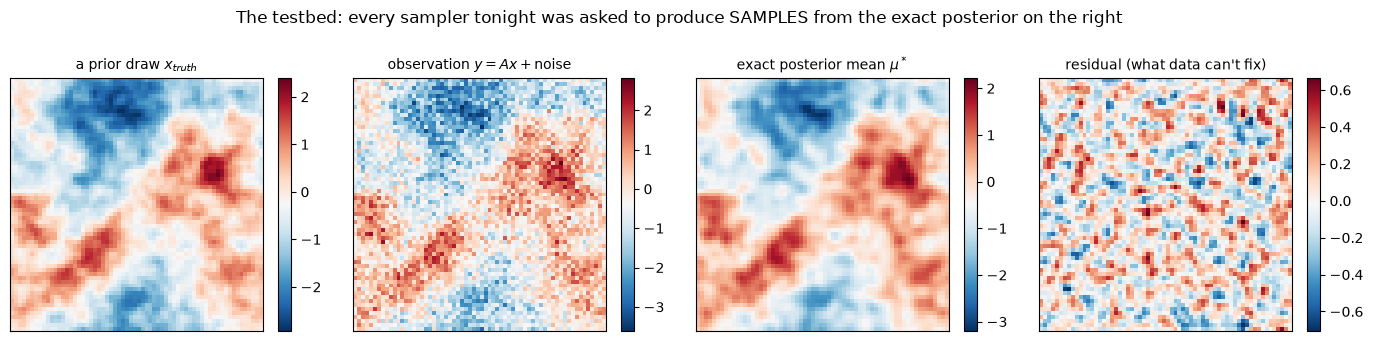

This is just Wiener filtering — the point is that the FULL posterior (mean AND covariance, mode by mode) is known exactly.


In [1]:
# Setup + a picture of the testbed: prior draw, observation, exact posterior mean
import json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve() if Path("../results").exists() else Path(
    "/home/tersenov/software/tilt-audit")
PR = Path("/home/tersenov/software/particle-reasoners")
rng = np.random.default_rng(7)

def load(*patterns, root=ROOT / "results"):
    rows = []
    for pat in patterns:
        for f in glob.glob(str(root / pat)):
            rows += [json.loads(l) for l in open(f) if l.strip()]
    return pd.DataFrame(rows)

# --- tiny self-contained re-implementation of the testbed (numpy only) ---
n = 64
k1 = np.fft.fftfreq(n, d=1/n)
KX, KY = np.meshgrid(k1, k1, indexing="ij")
K = np.hypot(KX, KY)
P = np.maximum(K, 1.0) ** (0.96 - 4.0) * np.exp(-(K / (0.7 * n / 2)) ** 2)
P /= P.mean()                          # unit pixel variance
a = np.exp(-0.5 * (K / (0.25 * n)) ** 2)   # smoothing operator
def draw_grf():
    white = np.fft.fft2(rng.normal(size=(n, n)))
    return np.fft.ifft2(white * np.sqrt(P)).real
x_truth = draw_grf()
s_obs = 0.5
y_map = np.fft.ifft2(np.fft.fft2(x_truth) * a).real + s_obs * rng.normal(size=(n, n))
# Wiener posterior mean for a mid-strength tilt (b chosen for illustration)
b = 0.05
Yk = np.fft.fft2(y_map)
Sig = 1.0 / (1.0 / P + a**2 / b)
mu_k = Sig * a * Yk / b
post_mean = np.fft.ifft2(mu_k).real

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, img, title in zip(
        axes, [x_truth, y_map, post_mean, x_truth - post_mean],
        ["a prior draw $x_{truth}$", "observation $y = Ax + $noise",
         "exact posterior mean $\\mu^*$", "residual (what data can't fix)"]):
    im = ax.imshow(img, cmap="RdBu_r"); ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("The testbed: every sampler tonight was asked to produce SAMPLES "
             "from the exact posterior on the right", y=1.05)
plt.tight_layout(); plt.show()
print("This is just Wiener filtering — the point is that the FULL posterior "
      "(mean AND covariance, mode by mode) is known exactly.")

## 3a. Background: what a diffusion model actually is

Forget neural networks for a moment. The problem diffusion models solve is ancient:
**you have samples from a complicated distribution $p(x)$ and want a machine that
generates more of them.** Direct density modeling is hard. The diffusion trick is to
convert this one hard problem into a *sequence of easy ones*:

1. Take your data and progressively drown it in Gaussian noise. After enough noise,
   the distribution is just $\mathcal{N}(0, I)$ — trivial to sample.
2. Learn to undo **one small noising step at a time**. Each undo step is a tiny,
   nearly-Gaussian inference problem — much easier than modeling $p$ wholesale.
3. To generate: start from pure noise and run the undo steps backwards.

The undoing turns out to require exactly one object at each noise level $t$: the
**score** of the noisy distribution,
$$s_t(x) \;=\; \nabla_x \log p_t(x),$$
the vector field that points "uphill in probability". Intuition: if I hand you a
noisy field and you know which direction makes it *more typical*, you can walk it
back toward the data manifold. Anderson's classic result (1982) makes this exact:
the noising process run in reverse is again a diffusion, with the score as its extra
drift term (equation below).

Why is the score *learnable*? Because of a beautiful identity (denoising score
matching): the score of the noisy marginal is equivalent to the conditional
expectation of the clean signal — so you can train a network by the utterly mundane
task of **predicting the noise you just added**. That's the entire training loop of
every diffusion model: add noise, predict it, repeat. No partition functions, no
adversarial games.

The cosmology connection you already own: a score model trained on N-body-derived
convergence maps is a *simulation prior* — it plays the exact role $\mathcal{N}(0,C)$
plays in Wiener filtering, but for the full non-Gaussian field. Tonight's testbed
deliberately uses the Gaussian case so that everything the samplers do can be checked
against Wiener-posterior closed forms.


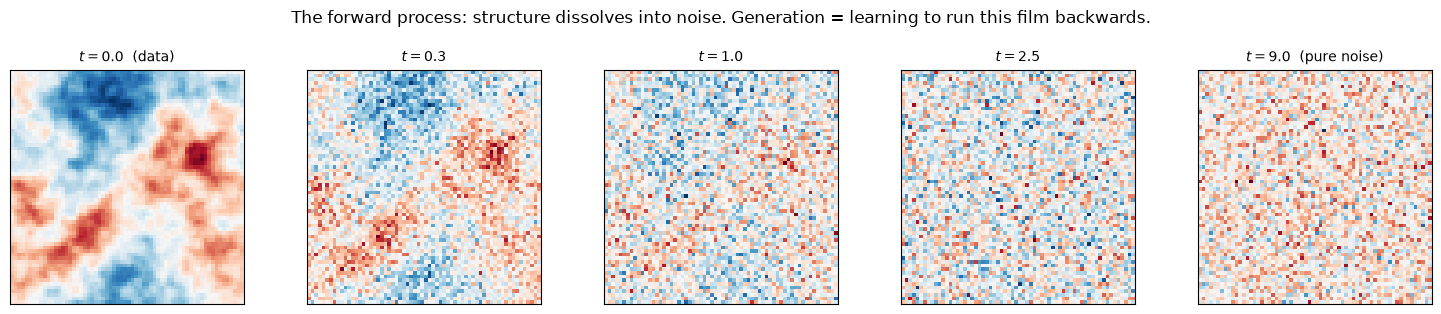

In [2]:
# Visual: the forward (noising) process on a real GRF — the "film strip"
ts_show = [0.0, 0.3, 1.0, 2.5, 9.0]
fig, axes = plt.subplots(1, len(ts_show), figsize=(15, 3))
for ax, t in zip(axes, ts_show):
    alpha_t, sig_t = np.exp(-t), np.sqrt(1 - np.exp(-2 * t))
    xt = alpha_t * x_truth + sig_t * rng.normal(size=(n, n))
    ax.imshow(xt, cmap="RdBu_r"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"$t = {t}$" + ("  (data)" if t == 0 else
                                 "  (pure noise)" if t == 9 else ""), fontsize=10)
plt.suptitle("The forward process: structure dissolves into noise. Generation = "
             "learning to run this film backwards.", y=1.03)
plt.tight_layout(); plt.show()

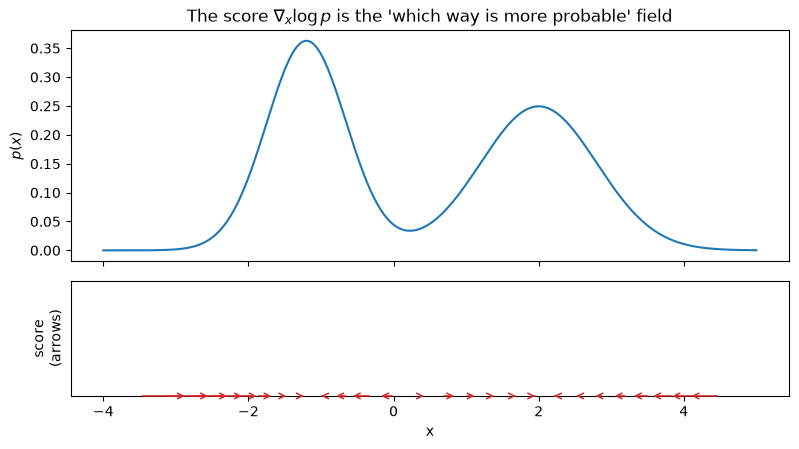

Following the arrows (plus the right amount of noise) IS sampling. That's the reverse diffusion.


In [3]:
# Visual: what "the score" means, in 1-D where you can see it
from scipy.stats import norm as gauss
xs = np.linspace(-4, 5, 400)
p_mix = 0.5 * gauss.pdf(xs, -1.2, 0.55) + 0.5 * gauss.pdf(xs, 2.0, 0.8)
logp = np.log(p_mix); score = np.gradient(logp, xs)
fig, axes = plt.subplots(2, 1, figsize=(8, 4.6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(xs, p_mix, "C0"); axes[0].set_ylabel("$p(x)$")
axes[0].set_title("The score $\\nabla_x \\log p$ is the 'which way is more probable' field")
for x0 in np.linspace(-3.5, 4.5, 26):
    s = np.interp(x0, xs, score)
    axes[1].annotate("", xy=(x0 + 0.11 * np.clip(s, -6, 6), 0), xytext=(x0, 0),
                     arrowprops=dict(arrowstyle="->", color="C3", lw=1.1))
axes[1].axhline(0, color="gray", lw=.5); axes[1].set_yticks([])
axes[1].set_xlabel("x"); axes[1].set_ylabel("score\n(arrows)")
plt.tight_layout(); plt.show()
print("Following the arrows (plus the right amount of noise) IS sampling. "
      "That's the reverse diffusion.")

## 3b. The reverse process, Tweedie, and our closed-form playground

Now the machinery, concretely. **Forward (noising) process** — an
Ornstein–Uhlenbeck SDE; in our convention, at time $t$:
$$x_t = e^{-t} x_0 + \sqrt{1 - e^{-2t}}\;\varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I),$$
so at $t=0$ you have data and by $t_f = 9$ you have essentially pure white noise.

**The reverse (denoising) process.** Run time backwards. The magic identity: to
reverse the noising you only need the **score** $\nabla_x \log p_t(x)$ — "which
direction is uphill in probability" — of the noisy marginals:
$$dx = \big[\,x + 2\,\nabla_x \log p_t(x)\,\big]\,d\tau + \sqrt{2}\, dW \qquad (\tau = t_f - t).$$
Trained models *learn* this score from data. For our Gaussian prior it's exact and
per-mode: $\nabla \log p_t = -x_k / V_t(k)$ with $V_t = e^{-2t} P_k + (1 - e^{-2t})$.

Two more closed forms we use constantly. The **denoiser** (Tweedie's formula) — the
best guess of the clean field given the noisy one:
$$\hat{x}_0(x_t) \equiv \mathbb{E}[x_0 \mid x_t] = \frac{e^{-t} P_k}{V_t(k)}\, x_t,$$
and its **uncertainty** $\mathrm{Var}[x_0|x_t] = P_k(1-e^{-2t})/V_t(k)$ — the piece
the biased methods throw away.

**Steering.** All of tonight's samplers run this reverse process but try to bend it
so that it lands on the *tilted* target $\sigma$ instead of the prior. They differ in
*how* they bend it — and that's where the biases live.

Two implementation notes that mattered (both caught by smoke tests before any real
run): the reverse process must be integrated on a **log-spaced time grid** (all the
data-information arrives near $t\to 0$; a uniform grid visibly biases even the exact
method), and stiff guidance terms need an **exponential integrator** (naive Euler
literally explodes at realistic steering strengths — error $10^{42}$, not subtle).


## 4. The contestants: six ways to steer one diffusion

For each sampler: the idea, the intuition for what goes wrong, and its "day job" in
the wider world.

**(0) Oracle** — draws directly from the exact per-mode posterior $\mathcal{N}(\mu^*, \Sigma^*)$.
Not a competitor: it defines the **finite-$N$ floor**. With $N$ particles even perfect
sampling shows nonzero empirical error; every other method is judged as a *ratio to
this floor*. (The pre-registered kill rule: if no method exceeds $3\times$ the floor
anywhere, the phenomenon is too small to care about — kill the program.)

**(1) DPS-style plug-in guidance** — the field's workhorse (Diffusion Posterior
Sampling). At each reverse step, add a data-pull term: the gradient of
$\log \mathcal{N}(y;\, A\hat{x}_0(x_t),\, b)$. Spot the sleight of hand: it plugs the
*point estimate* $\hat{x}_0$ into the likelihood and **ignores the denoiser's
uncertainty** $\mathrm{Var}[x_0|x_t]$. Early in the reverse process that uncertainty
is as large as the prior itself, so the data gets far too much pull. Prediction:
systematically **over-concentrated** posteriors (too narrow, overshot means) — the
Bayesian's classic sin of double-counting confidence.

**(2) Exact guidance (control arm)** — same structure but keeps the variance
inflation term: pull $\propto \mathcal{N}(y; A\hat{x}_0, b + A\,\mathrm{Var}[x_0|x_t]A^\top)$.
In this linear-Gaussian world this is *exactly right*, so this arm measures pure
discretization error — it isolates "scheme bias" from "integrator sloppiness".

**(3) Reward-as-potential particle filter ("SAP")** — run $N$ diffusions in parallel;
at *every* step, weight each particle by $e^{r(\hat{x}_0)/\beta}$ and resample
(kill low-reward particles, duplicate high-reward ones). This is the continuous twin
of score-as-potential test-time search on LLMs. The flaw: the *full* reward is
re-applied at every one of $T$ steps, so selection pressure **compounds with depth** —
the population ends up over-tilted ("colder" than the target), or, when the reward is
harsh, collapses onto a single lineage entirely.

**(4) Proper twisted SMC** — the mathematically correct member. Sequential Monte
Carlo whose importance weights use the **optimal twist**
$\psi_t(x_t) = \mathbb{E}[e^{r(x_0)/\beta} \mid x_t]$ — here available in closed form
per mode:
$$\psi_t(x_t) = \mathcal{N}\!\big(y;\; A\hat{x}_0(x_t),\; b + A\,\mathrm{Var}[x_0|x_t]A^\top\big).$$
With proposals drawn from the twist-conjugate kernel, the incremental weights are
*provably identically zero* in this substrate (a tower-property identity) — which we
exploited as a machine-precision self-test of every formula in the stack: any algebra
error anywhere would show up as nonzero weights. It also produces an unbiased
evidence estimate $\hat{Z}$ — the seed of the "runtime certificate" idea.

**(5) Terminal importance sampling** — the lazy baseline: run the *unguided* diffusion
$N$ times, then reweight the finished samples by $e^{r(x_0)/\beta}$. Consistent as
$N\to\infty$, but in high dimension the weights degenerate instantly (one particle
takes all the weight) — the continuous twin of best-of-$N$.

One design decision worth knowing: the *naive* twisted variant that uses $\psi$-ratios
as weights but keeps *prior* proposals is formally unbiased too — and it collapses
catastrophically beyond a few hundred dimensions (its $\log\hat{Z}$ lands hundreds of
log-units below truth in any single run). We kept it as a diagnostic arm: it is the
cleanest demonstration that "formally unbiased" and "works" are different claims —
which is precisely what a certificate should detect.


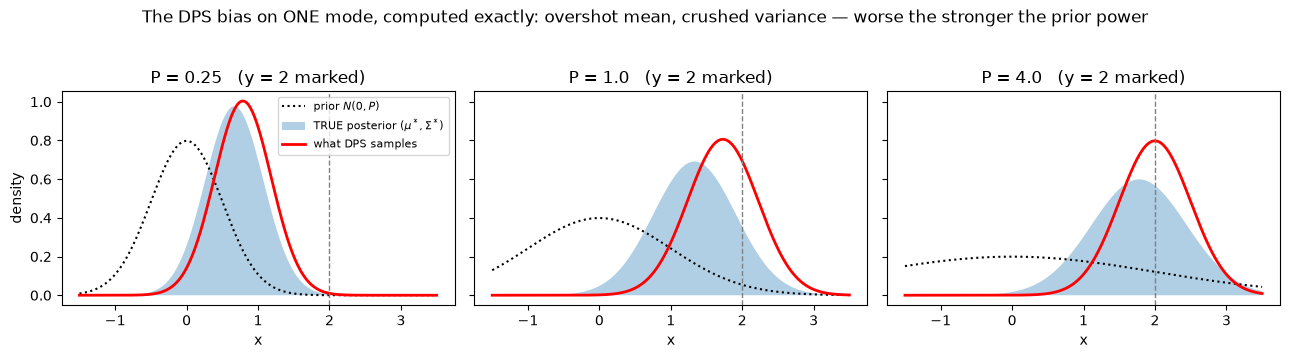

These six numbers were pre-registered in the plan as gate T-G2: the
implemented sampler had to reproduce them to ~2% before any GPU run.


In [4]:
# Intuition anchor: the pre-registered single-mode numbers (gate T-G2).
# One Fourier mode, prior variance P, observation y=2, effective noise b=0.5:
# solve the reverse diffusion EXACTLY (moment ODEs) with DPS vs exact guidance.
from scipy.stats import norm as gauss

table = {   # P : (DPS mean, DPS var, exact mean = mu*, exact var = Sigma*)
    0.25: (0.787, 0.158, 0.667, 0.167),
    1.00: (1.729, 0.245, 1.333, 0.333),
    4.00: (1.999, 0.250, 1.778, 0.444),
}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
xs = np.linspace(-1.5, 3.5, 400)
for ax, (Pk, (dm, dv, em, ev)) in zip(axes, table.items()):
    ax.plot(xs, gauss.pdf(xs, 0, np.sqrt(Pk)), "k:", label="prior $N(0,P)$")
    ax.fill_between(xs, gauss.pdf(xs, em, np.sqrt(ev)), alpha=.35,
                    label="TRUE posterior $(\\mu^*,\\Sigma^*)$")
    ax.plot(xs, gauss.pdf(xs, dm, np.sqrt(dv)), "r-", lw=2, label="what DPS samples")
    ax.axvline(2.0, color="gray", lw=1, ls="--")
    ax.set_title(f"P = {Pk}   (y = 2 marked)"); ax.set_xlabel("x")
axes[0].set_ylabel("density"); axes[0].legend(fontsize=8)
plt.suptitle("The DPS bias on ONE mode, computed exactly: overshot mean, "
             "crushed variance — worse the stronger the prior power", y=1.04)
plt.tight_layout(); plt.show()
print("These six numbers were pre-registered in the plan as gate T-G2: the")
print("implemented sampler had to reproduce them to ~2% before any GPU run.")

## 4b. Background: importance sampling, particle filters, and twists

The other half of the sampler zoo is Monte-Carlo-with-weights, so here is the
thirty-second refresher plus the one concept that may be new (the *twist*).

**Importance sampling (IS).** Want averages under $\sigma$, can only sample from
$q$: draw $x^{(i)} \sim q$, weight $w^{(i)} = \sigma(x^{(i)})/q(x^{(i)})$, done.
Unbiased, consistent... and famously fragile: if $q$ misses where $\sigma$ lives,
one sample hogs all the weight. The standard health meter is the **effective sample
size**, $\mathrm{ESS} = 1/\sum_i \bar w_i^2 \in [1, N]$: how many of your $N$
particles are actually contributing. The killer fact — worth seeing once (demo
below) — is that for product-form targets the weight variance grows exponentially
with dimension. One-shot IS is dead on arrival at $d = 4096$; that's precisely the
terminal-IS / best-of-$N$ arm's failure.

**Sequential Monte Carlo (SMC / particle filters).** The fix: don't pay the whole
importance-weight bill at once. Move a *population* of particles through a sequence
of gently-changing distributions; at each stage, reweight a little and — when ESS
drops below a threshold — **resample** (clone the heavy, cull the light) so the
population keeps living where the probability is. Resampling is the double-edged
sword: it prevents weight collapse, but every resampling event throws away diversity;
done wrong or too often, the population inbreeds (that's SAP's disease).

**Twists.** In a diffusion, the natural sequence of distributions is "the posterior,
seen at each noise level". The ideal reweighting function at level $t$ is the
lookahead from the derivation above,
$\psi_t(x_t) = \mathbb{E}[L(x_0)\,|\,x_t]$ — called the **optimal twist**. It scores
each *noisy* particle by how much likelihood it will eventually be able to reach.
Real applications must approximate $\psi_t$ (that's an active literature); in our
testbed it's available in closed form, which is exactly what makes the pilot an
*oracle* test: we can run the correct algorithm correctly and see what everything
else loses.

One subtlety that produced the night's most instructive negative result: it is not
enough to *weight* by the right twist — you should also *propose* with it (move
particles with the twist-aware dynamics). Weight-only twisting is formally unbiased
but its weights still have exploding variance in high $d$; it collapsed just like
naive IS. Proper SMC = right weights **and** right proposals.


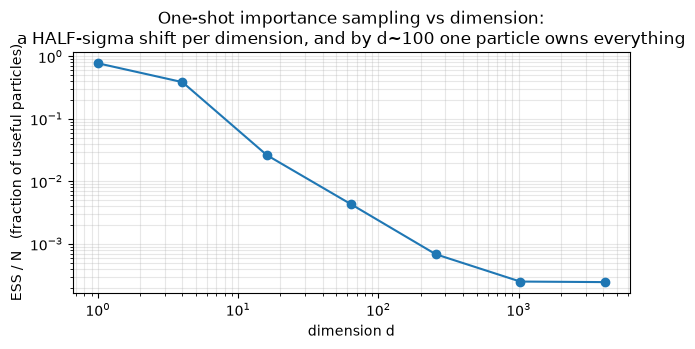

This is why 'generate N samples and reweight at the end' (best-of-N) cannot
work on fields — and why the sequential machinery exists at all.


In [5]:
# Demo: why one-shot importance sampling dies with dimension.
# Target: N(0.5,1)^d. Proposal: N(0,1)^d. Watch ESS/N crater as d grows.
Ns = 4096
dims = [1, 4, 16, 64, 256, 1024, 4096]
ess_frac = []
for d in dims:
    z = rng.normal(size=(Ns, d))
    logw = (0.5 * z - 0.125).sum(axis=1)          # log N(z;0.5,1)/N(z;0,1) per dim
    w = np.exp(logw - logw.max()); w /= w.sum()
    ess_frac.append(1.0 / (w**2).sum() / Ns)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(dims, ess_frac, "o-")
ax.set(xscale="log", yscale="log", xlabel="dimension d",
       ylabel="ESS / N   (fraction of useful particles)",
       title="One-shot importance sampling vs dimension:\n"
             "a HALF-sigma shift per dimension, and by d~100 one particle owns everything")
ax.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()
print("This is why 'generate N samples and reweight at the end' (best-of-N) cannot")
print("work on fields — and why the sequential machinery exists at all.")

## 5. How we keep score

All metrics are exact-or-honest, computed against $(\mu^*, \Sigma^*)$:

- **$W_2$ (Wasserstein-2)** and **KL divergence** between the sampler's output
  (summarized by per-mode weighted mean/variance) and the truth — Gaussian closed
  forms, summed over modes. The same estimator applied to the oracle gives the
  finite-$N$ floor, so the estimator's own bias cancels in ratios. (Handy fact the
  data confirmed exactly: the oracle's KL floor is $d/N$ nats.)
- **Effective temperature $\gamma^*$** — fit the sampler's output within the family
  $\sigma_\gamma \propto p\, e^{\gamma r/\beta}$. If $\gamma^* = 1$ you sampled the
  right tilt; $\gamma^* > 1$ you *over*-tilted (**"cold"**: too narrow, too far toward
  the data); $\gamma^* < 1$ under-tilted (**"warm"**). One caveat learned the hard way:
  a single scalar can't describe a *collapsed* population (variance $\to 0$ with the
  mean stuck) — we log mean-tracking and variance-ratio separately for that.
- **Coverage**: does the sampler's 68% credible interval for simple functionals (mean
  field value, band powers) contain 68% of the true posterior mass? Under-coverage =
  overconfidence, the observable a downstream analysis would actually get burned by.
- **Evidence error** $\log\hat{Z} - \log Z$: only the correct SMC method even offers
  an estimate; the analytic $Z$ lets us check its honesty.

**Pre-registration discipline.** Five predictions (P-d … P-h) were frozen in the
research log *before* the first GPU job — including the kill criterion and, at 25%
believed probability, the "this is all negligible" branch. Four test gates (analytic
tables, unbiasedness checks, exact identities) had to pass before any big run. All
scoring happened the morning after, jointly.


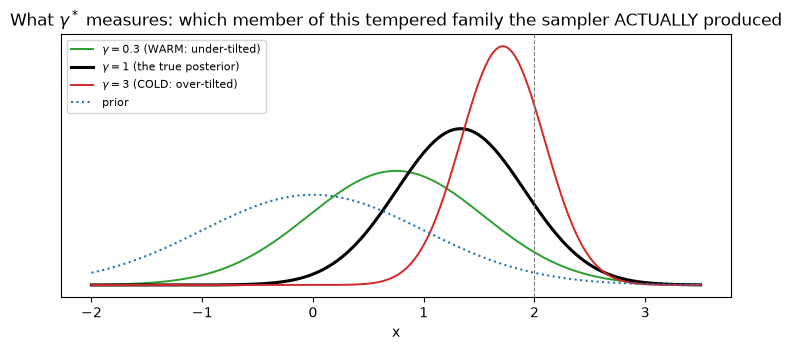

In [6]:
# Visual: the "effective temperature" family in 1-D. gamma tempers the tilt:
# sigma_gamma ∝ p * exp(gamma * r / beta). gamma=1 is the true posterior.
P_, a_, y_, b_ = 1.0, 1.0, 2.0, 0.5
xs = np.linspace(-2, 3.5, 400)
fig, ax = plt.subplots(figsize=(7, 3.6))
for g_, c_ in [(0.3, "C2"), (1.0, "k"), (3.0, "C3")]:
    Sg = 1 / (1 / P_ + g_ * a_**2 / b_); mg = Sg * g_ * a_ * y_ / b_
    lbl = {0.3: "$\\gamma=0.3$ (WARM: under-tilted)", 1.0: "$\\gamma=1$ (the true posterior)",
           3.0: "$\\gamma=3$ (COLD: over-tilted)"}[g_]
    ax.plot(xs, gauss.pdf(xs, mg, np.sqrt(Sg)), color=c_, lw=2.2 if g_ == 1 else 1.4,
            label=lbl)
ax.plot(xs, gauss.pdf(xs, 0, 1), "C0:", label="prior")
ax.axvline(2, color="gray", ls="--", lw=.8)
ax.legend(fontsize=8); ax.set_xlabel("x"); ax.set_yticks([])
ax.set_title("What $\\gamma^*$ measures: which member of this tempered family "
             "the sampler ACTUALLY produced")
plt.tight_layout(); plt.show()

## 6. Headline result: the confirmatory grid

The frozen grid: samplers × tilt strength $\{0.5, 1, 2, 4\}\sigma$ × grid size
$\{16^2, 32^2, 64^2\}$ × particles $N \in \{16, 64, 256\}$ × 3 seeds (later densified
to ~10 seeds, plus exploratory tilt strengths down to $0.125\sigma$).

**How to read the money plot below**: each panel is one grid size; x-axis is how hard
you steer; y-axis (log!) is total $W_2$ error to the true posterior; the black dashed
line is the oracle floor — perfection at this particle count. Distance above the
dashed line = *real* sampler bias, not finite-sample noise.


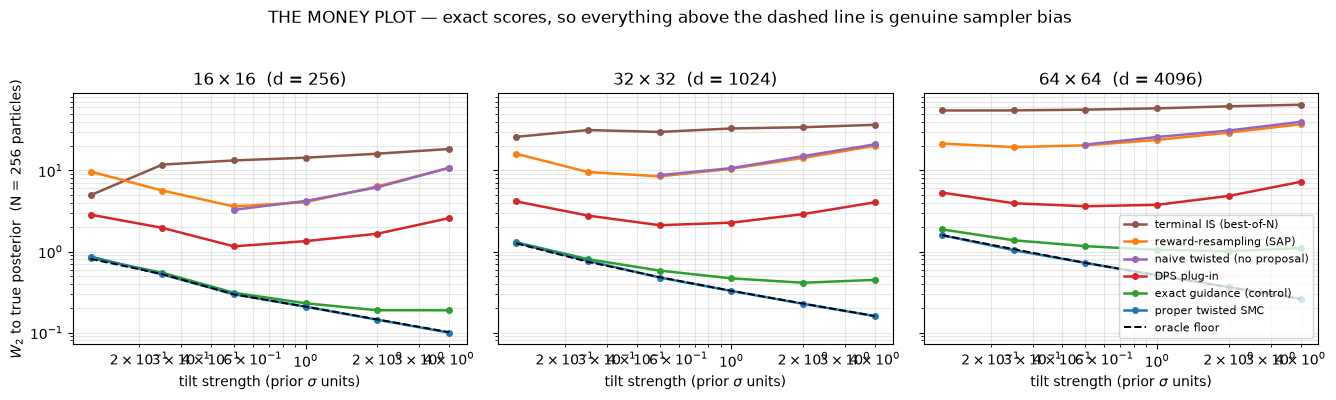

W2 as a MULTIPLE of the oracle floor (64x64, N=256) — kill rule was 'nothing exceeds 3x':
sampler   dps    sap  terminal_is  twisted
shift                                     
0.125     3.3   13.5         34.5      1.0
0.250     3.7   18.2         51.4      1.0
0.500     5.0   28.2         77.8      1.0
1.000     7.4   46.7        114.5      1.0
2.000    13.4   81.1        171.3      1.0
4.000    27.7  142.1        247.5      1.0


In [7]:
df = load("t1_core.jsonl", "t1_controls.jsonl", "t3_seeds.jsonl", "t1_weak.jsonl")
df = df[df["T"] == 64]
med = df.groupby(["dim", "shift", "N", "sampler"]).w2.median().reset_index()
N_SHOW = 256
sub = med[med.N == N_SHOW]
pretty = {"dps": "DPS plug-in", "sap": "reward-resampling (SAP)",
          "terminal_is": "terminal IS (best-of-N)", "twisted": "proper twisted SMC",
          "twisted_potential": "naive twisted (no proposal)",
          "exact_guidance": "exact guidance (control)", "oracle": "oracle floor"}
colors = {"dps": "C3", "sap": "C1", "terminal_is": "C5", "twisted": "C0",
          "twisted_potential": "C4", "exact_guidance": "C2", "oracle": "k"}
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharey=True)
for ax, dim in zip(axes, [16, 32, 64]):
    for s in ["terminal_is", "sap", "twisted_potential", "dps",
              "exact_guidance", "twisted", "oracle"]:
        g = sub[(sub.dim == dim) & (sub.sampler == s)].sort_values("shift")
        if not len(g):
            continue
        style = dict(color=colors[s], marker="o", lw=1.8, ms=4)
        if s == "oracle":
            style.update(ls="--", marker=None, lw=1.4)
        ax.plot(g["shift"], g.w2, label=pretty[s], **style)
    ax.set(xscale="log", yscale="log", xlabel="tilt strength (prior $\\sigma$ units)",
           title=f"${dim}\\times{dim}$  (d = {dim*dim})")
    ax.grid(alpha=.3, which="both")
axes[0].set_ylabel(f"$W_2$ to true posterior  (N = {N_SHOW} particles)")
axes[2].legend(fontsize=8, loc="lower right")
plt.suptitle("THE MONEY PLOT — exact scores, so everything above the dashed line "
             "is genuine sampler bias", y=1.04)
plt.tight_layout(); plt.show()

# ratio-to-floor table at 64^2
oracle = med[med.sampler == "oracle"].rename(columns={"w2": "floor"})
t = med.merge(oracle[["dim", "shift", "N", "floor"]], on=["dim", "shift", "N"])
t["ratio"] = t.w2 / t.floor
show = (t[(t.dim == 64) & (t.N == 256) &
          t.sampler.isin(["dps", "sap", "twisted", "terminal_is"])]
        .pivot_table(index="shift", columns="sampler", values="ratio").round(1))
print("W2 as a MULTIPLE of the oracle floor (64x64, N=256) — kill rule was 'nothing exceeds 3x':")
print(show.to_string())

**What you're seeing, sampler by sampler:**

- **Proper twisted SMC (blue) sits exactly on the oracle floor, everywhere.** All 36
  cells within 0.96–1.06× floor, $\gamma^* = 1.00$, and its evidence estimate equals
  the analytic $Z$ to machine precision. Correct method, correct in practice.
- **The control (green) also hugs the floor** → discretization is a solved non-issue;
  whatever the others do wrong is *scheme*, not numerics. (We verified the DPS curve
  *analytically* the next morning: an independent stiff-ODE integration of the DPS
  dynamics predicts the measured $W_2$ to 0.7–2.8%.)
- **DPS (red) is biased everywhere and the bias grows with steering strength** —
  5× floor at the *gentlest* realistic tilt, 28× at strong tilts. Its
  $\gamma^* \approx 1.3$–1.4: over-tilted, over-confident, under-covering (the 68%
  intervals cover ~0% at strong tilts). This is prediction P-d, scored **HIT**.
- **Reward-resampling (orange) is worse than DPS everywhere** — and its failure mode
  at strong tilts is total: variance collapse without the mean even reaching the
  target. More on its depth-dependence next.
- **Terminal IS (brown) is the disaster you'd expect** in $d \geq 256$: weight
  degeneracy, effectively stuck at the prior.
- **The naive twisted variant (purple) tracks SAP** — being formally unbiased did not
  save it. This is the certificate story's exhibit A.
- **Kill criterion:** at $N = 256$, DPS never gets below ~3.3× floor even at
  $0.125\sigma$ tilts (exploratory arm). The "it's all negligible" branch (P-h,
  believed at 25%) is dead. **GO.**


## 7. The depth law: SAP runs cold, but only if you give it enough steps

The frozen grid ran at $T=64$ diffusion steps, where SAP mostly showed *collapse*
(variance → 0, mean stuck) rather than the predicted clean "cold" signature
$\gamma^* > 1$. The resolution came from the step-count sweep: **selection pressure
compounds once per step, so the over-tilt grows with depth.**

This is the same law measured on LLM test-time search in particle-reasoners (damage
compounds with search depth) — reproduced here in continuous space with exact ground
truth. At the step counts practitioners actually use ($T \gtrsim 256$), SAP is
unambiguously cold. Prediction P-e: **HIT, depth-qualified.**

Meanwhile DPS is flat in $T$ — its bias is a property of the *continuous* dynamics,
not of discretization. Two different diseases, cleanly separated.


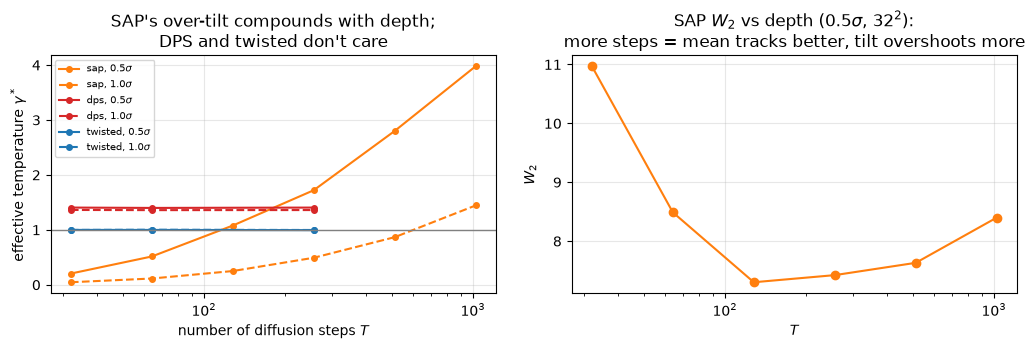

In [8]:
ts = load("t1_tsens.jsonl", "t1_core.jsonl")
sel = ts[(ts.dim == 32) & (ts.N == 256) & ts["shift"].isin([0.5, 1.0])]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
for s, c in [("sap", "C1"), ("dps", "C3"), ("twisted", "C0")]:
    for shift, ls in [(0.5, "-"), (1.0, "--")]:
        g = (sel[(sel.sampler == s) & (sel["shift"] == shift)]
             .groupby("T").gamma_star.median().reset_index().sort_values("T"))
        if len(g) > 1:
            axes[0].plot(g["T"], g.gamma_star, ls, color=c, marker="o", ms=4,
                         label=f"{s}, {shift}$\\sigma$")
axes[0].axhline(1.0, color="gray", lw=1)
axes[0].set(xscale="log", xlabel="number of diffusion steps $T$",
            ylabel="effective temperature $\\gamma^*$",
            title="SAP's over-tilt compounds with depth;\nDPS and twisted don't care")
axes[0].legend(fontsize=7); axes[0].grid(alpha=.3)
g = (sel[(sel.sampler == "sap") & (sel["shift"] == 0.5)]
     .groupby("T").w2.median().reset_index().sort_values("T"))
axes[1].plot(g["T"], g.w2, "o-", color="C1")
axes[1].set(xscale="log", xlabel="$T$", ylabel="$W_2$",
            title="SAP $W_2$ vs depth (0.5$\\sigma$, 32$^2$):\nmore steps = mean tracks better, tilt overshoots more")
axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8. No rescue from high dimension — and the misspecification trap

**Dimension.** A theory paper (arXiv:2502.07849) proved that classifier-free
guidance's distortions *vanish* as $d\to\infty$, and a pre-read verified that
mechanism cannot operate for reward tilts — the bias should be *extensive* (per-mode
$O(1)$, total $\propto d$). Measured: DPS total KL grows 29 → 200 → 1738 → 16372 nats
from $d=256$ to $d=16384$, always ~two orders of magnitude above the oracle floor
(which is exactly $d/N$ nats — a satisfying internal check). No blessing of
dimensionality is coming to save the biased methods.

**Misspecification** — the part closest to home. We contaminated the *score* the
samplers believe (spectral slope tilted by $\varepsilon$ — think "the emulator was
trained on the wrong feedback model") while measuring error against the *true*
posterior. Three cleanly different behaviors:

1. **Proper SMC passes contamination through exactly 1:1.** Its weights are built
   from the same wrong model, so conjugacy holds *with respect to the wrong model* —
   it faithfully and confidently samples the wrong posterior. The prediction said
   proper weighting would "partially absorb" the error; that intuition is **wrong**,
   and knowing it's wrong is worth more than the prediction. *Weights cannot know the
   model is lying.*
2. **DPS interacts with contamination sign-dependently.** One sign *amplifies* its
   over-concentration; the other sign *cancels* against it — at $\varepsilon = -0.3$
   the effective temperature comes out $\gamma^* = 0.98$, i.e. a doubly-broken
   pipeline that looks calibrated on the temperature diagnostic ($W_2$ still catches
   it at 6× floor). That is the baryonic-feedback trap in miniature: two wrongs
   faking a right. Audits need multiple, mechanistically different metrics.
3. **SAP's own collapse masks contamination entirely** — it's too broken to notice.

Prediction P-g: **HIT with the mechanism corrected.**


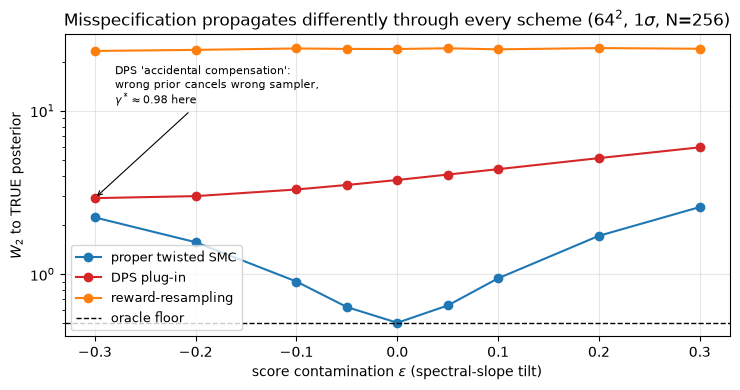

In [9]:
mis = load("t1_misspec.jsonl")
core = load("t1_core.jsonl")
base = core[(core.dim == 64) & (core.N == 256) & (core["shift"] == 1.0)]
rows = []
for s in ["dps", "twisted", "sap"]:
    rows.append({"sampler": s, "eps": 0.0,
                 "w2": base[base.sampler == s].w2.median()})
for (s, e), g in mis[(mis.N == 256) & (mis["shift"] == 1.0)].groupby(["sampler", "eps"]):
    rows.append({"sampler": s, "eps": e, "w2": g.w2.median()})
lad = pd.DataFrame(rows)
floor = base[base.sampler == "oracle"].w2.median()

fig, ax = plt.subplots(figsize=(7.5, 4))
for s, c, lbl in [("twisted", "C0", "proper twisted SMC"), ("dps", "C3", "DPS plug-in"),
                  ("sap", "C1", "reward-resampling")]:
    g = lad[lad.sampler == s].sort_values("eps")
    ax.plot(g.eps, g.w2, "o-", color=c, label=lbl)
ax.axhline(floor, color="k", ls="--", lw=1, label="oracle floor")
ax.annotate("DPS 'accidental compensation':\nwrong prior cancels wrong sampler,\n$\\gamma^*\\approx 0.98$ here",
            xy=(-0.3, lad[(lad.sampler=='dps') & (lad.eps==-0.3)].w2.iloc[0]),
            xytext=(-0.28, 11), fontsize=8, arrowprops=dict(arrowstyle="->", lw=.8))
ax.set(yscale="log", xlabel="score contamination $\\varepsilon$ (spectral-slope tilt)",
       ylabel="$W_2$ to TRUE posterior", title="Misspecification propagates differently "
       "through every scheme (64$^2$, 1$\\sigma$, N=256)")
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 9. Real (trained) score networks, and a theorem put on the scale

**Learned scores (tier T2).** Overnight we also trained three small U-Nets
(1.4M params, denoising score matching on fresh GRF draws — one clean, two on
contaminated spectra) and reran the comparison with the *learned* score plugged in,
plus a "pathway control" (analytic score pushed through the exact same
practitioner-style sampling pathway). That splits any real pipeline's error into four
separately measured pieces — **sampler scheme / sampling-pathway choices / network
score error / prior misspecification** — on top of the finite-$N$ floor. This
decomposition axis is the thing none of the prior-art benchmarks have. One
finding worth flagging: for the correct SMC method, the *pathway* choices (the
standard ancestral sampling kernel) cost more than the network's score error did.

**A theorem on the scale (tier T4.1).** The adjoint-matching paper (arXiv:2409.08861)
proves reward-finetuning of a diffusion model converges to the *intended* tilted
distribution **only** under a specific "memoryless" noise schedule. Mapped into our
setup, that schedule is exactly $\sigma^2 = 2$ (our standard reverse SDE), and the
whole family is analytically solvable here — so we computed the theorem's bias
*exactly*, no training loop needed: at short horizons the ordering is textbook-steep
(KL 0.09 → 43,000 as the schedule departs), while at long horizons mild violations
are harmless and the catastrophe concentrates exactly in the near-deterministic
(Flow-Matching/DDIM-style) limit practitioners prefer. A known theorem, but now with
exact numbers attached — and the harness produced them in minutes.


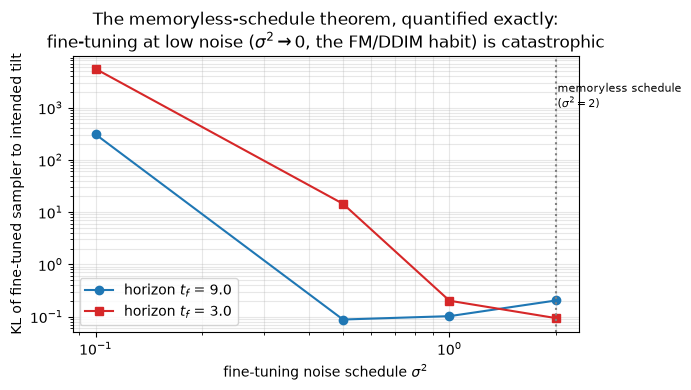

In [10]:
t41 = load("t41_memoryless.jsonl")
fig, ax = plt.subplots(figsize=(7, 4))
for tf, c, m in [(9.0, "C0", "o"), (3.0, "C3", "s")]:
    g = (t41[(t41.tf == tf) & (t41["shift"] == 1.0)]
         .groupby("sig2").kl.median().reset_index().sort_values("sig2"))
    ax.plot(g.sig2, g.kl, m + "-", color=c, label=f"horizon $t_f$ = {tf}")
ax.axvline(2.0, color="gray", ls=":", lw=1.5)
ax.text(2.02, 1e3, "memoryless schedule\n($\\sigma^2 = 2$)", fontsize=8)
ax.set(xscale="log", yscale="log", xlabel="fine-tuning noise schedule $\\sigma^2$",
       ylabel="KL of fine-tuned sampler to intended tilt",
       title="The memoryless-schedule theorem, quantified exactly:\n"
             "fine-tuning at low noise ($\\sigma^2\\to 0$, the FM/DDIM habit) is catastrophic")
ax.legend(); ax.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

## 10. The parallel track: the same disease in LLM test-time search

While the GPUs churned on fields, a third GPU ran the LLM side. Background for
this track, since it uses its own vocabulary:

**Test-time search.** To boost an LLM's math accuracy without retraining, generate
*many* candidate solutions and use a **process reward model (PRM)** — a second
network that scores partial solutions step by step — to steer the generation:
periodically rank the partial solutions, kill the low-scoring ones, duplicate the
high-scoring ones. If that sounds *exactly* like the reward-resampling particle
filter from the field side — it is. Same algorithm, discrete substrate. The
particle-reasoners project showed this search buys accuracy but quietly **destroys
calibration**: after resampling, "16 of 16 samples agree" no longer means the answer
is probably right, because the agreement was manufactured by selection, not evidence.

**The metrics.** For each problem, the method outputs a population of final answers
with weights. *Confidence* = weight share of the most popular answer; *accuracy* =
is that answer right; **AUROC** = across many problems, can the confidence *rank*
correct answers above wrong ones (1.0 = perfect ranking, 0.5 = coin flip, below 0.5 =
actively inverted). A confidence signal you can't rank with is a confidence signal
you can't act on.

Two experiments ran overnight:

**B1 — the "insurance" sweep.** Prior work showed that test-time search destroys the
answer-distribution's calibration signal. The proposed fix: reserve a fraction
$\alpha$ of the particle budget as a *never-resampled* i.i.d. stratum — search keeps
its accuracy win, the insurance stratum keeps an honest confidence estimate. The sweep
asks: how does the confidence signal's quality (AUROC: can confidence rank right
answers above wrong ones?) grow with $\alpha$, and what does the insurance cost in
accuracy?

Answer below: AUROC climbs from coin-flip to ~0.76 as the stratum grows, crossing the
pre-registered 0.65 threshold right at $\alpha = 0.25$; accuracy stays flat well past
that. Design insight: at 16 particles the real variable is the *integer* number of
insurance samples (round(16α)) — a "5% stratum" is one sample and carries no signal.


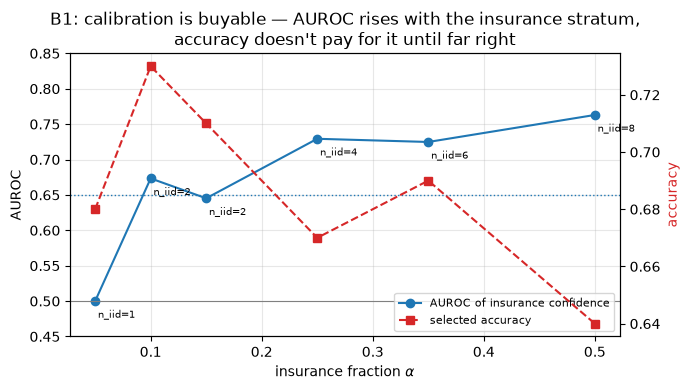

In [11]:
def auroc_np(c, k):
    c, k = np.asarray(c, float), np.asarray(k, int)
    p, n_ = c[k == 1], c[k == 0]
    if len(p) == 0 or len(n_) == 0: return np.nan
    return (p[:, None] > n_[None, :]).mean() + 0.5 * (p[:, None] == n_[None, :]).mean()

rows = []
for f in sorted(glob.glob(str(PR / "results/tables/reliability_alpha_*.jsonl"))):
    a_ = float(Path(f).stem.split("_")[-1])
    d = pd.DataFrame([json.loads(l) for l in open(f) if l.strip()])
    if len(d):
        rows.append({"alpha": a_, "auroc": auroc_np(d.confidence, d.modal_correct),
                     "acc": d.selected_correct.mean(), "n": len(d),
                     "n_iid": max(1, round(a_ * 16))})
b1 = pd.DataFrame(rows).sort_values("alpha")
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(b1.alpha, b1.auroc, "o-", color="C0", label="AUROC of insurance confidence")
ax1.axhline(0.65, color="C0", ls=":", lw=1); ax1.axhline(0.5, color="gray", lw=.8)
for _, r in b1.iterrows():
    ax1.annotate(f"n_iid={int(r.n_iid)}", (r.alpha, r.auroc), fontsize=7,
                 textcoords="offset points", xytext=(2, -12))
ax2 = ax1.twinx()
ax2.plot(b1.alpha, b1.acc, "s--", color="C3", label="selected accuracy")
ax1.set(xlabel="insurance fraction $\\alpha$", ylabel="AUROC", ylim=(.45, .85))
ax2.set_ylabel("accuracy", color="C3")
lines = ax1.get_lines()[:1] + ax2.get_lines()[:1]
ax1.legend(lines, [l.get_label() for l in lines], fontsize=8, loc="lower right")
ax1.set_title("B1: calibration is buyable — AUROC rises with the insurance stratum,\n"
              "accuracy doesn't pay for it until far right")
ax1.grid(alpha=.3); plt.tight_layout(); plt.show()

**B2 — a cautionary tale worth the price of the whole night.** The twin
experiment reran the search-vs-calibration comparison on a *different model family*
(DeepSeek R1-distill, a long chain-of-thought reasoner). The overnight numbers came
back absurd: **every** confidence signal anti-correlated with correctness — AUROC 0.17
for plain i.i.d. sampling, which is well-calibrated (≥0.7) on Qwen.

Morning autopsy, in three steps worthy of a detective story:

1. **Rows-only forensics**: 80% of R1's wrong answers had confidence exactly 1.0 with
   *one* distinct answer among 16 samples. Sixteen identical wrong answers on hard
   problems? Far more likely: sixteen *failed answer extractions*.
2. **Code inspection**: the harness pools every unparseable sample into a single
   `"<none>"` bucket that then *wins the vote* — manufactured unanimity.
3. **Causal test**: regenerate the same problems at the same 2048-token budget → 78%
   of samples truncate mid-reasoning, and extraction fails for 89% of truncated
   samples. Regenerate at a 12k budget → truncation 21%, extraction failures among
   finished samples 0%, accuracy on the "confidently wrong" problems jumps from 0.00
   to 0.56. **The inversion was measurement, not model.** R1 simply needs ~6k tokens
   of thinking per problem and was being cut off at 2k.

Three harness bugs were fixed as a result (output-file truncation on rerun, the
process-reward-model crashing on long traces, and the `"<none>"` vote-pooling), a
validity gate (`none_frac < 0.10` per row) was pre-registered, a 15-problem pilot
passed it (AUROC back to 0.75), and the full 3-seed rerun is running as this notebook
is being written. *The meta-lesson is the same one the GRF side teaches: reliability
failures in inference pipelines are usually silent, and the fix starts with
instrumentation that makes the failure visible.*


R1 truncation autopsy — same problems, two token budgets:
        truncation  extract_fail  modal_is_none  modal_accuracy  mean_tokens
budget                                                                      
2048          0.78          0.79           0.80             0.2      1911.89
12000         0.19          0.22           0.25             0.6      5888.91


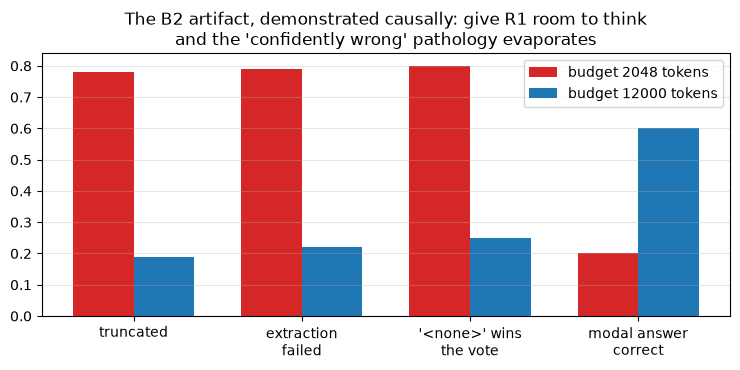

In [12]:
try:
    aut = pd.DataFrame([json.loads(l) for l in open(ROOT / "results/r1_autopsy.jsonl")
                        if l.strip()])
    aut2 = ROOT / "results/r1_autopsy_b12k_rest.jsonl"
    if aut2.exists():
        extra = pd.DataFrame([json.loads(l) for l in open(aut2) if l.strip()])
        aut = (pd.concat([aut, extra], ignore_index=True)
               .drop_duplicates(subset=["budget", "problem_id"], keep="last"))
    summ = aut.groupby("budget").agg(
        truncation=("trunc_rate", "mean"), extract_fail=("extract_fail_rate", "mean"),
        modal_is_none=("modal_is_none", "mean"), modal_accuracy=("modal_correct", "mean"),
        mean_tokens=("mean_tokens", "mean")).round(2)
    print("R1 truncation autopsy — same problems, two token budgets:")
    print(summ.to_string())
    x = np.arange(4); w = 0.36
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    for i, (b, c) in enumerate([(2048, "C3"), (12000, "C0")]):
        r = summ.loc[b]
        ax.bar(x + i*w, [r.truncation, r.extract_fail, r.modal_is_none,
                         r.modal_accuracy], w, color=c, label=f"budget {b} tokens")
    ax.set_xticks(x + w/2, ["truncated", "extraction\nfailed", "'<none>' wins\nthe vote",
                            "modal answer\ncorrect"])
    ax.set_title("The B2 artifact, demonstrated causally: give R1 room to think\n"
                 "and the 'confidently wrong' pathology evaporates")
    ax.legend(); ax.grid(alpha=.3, axis="y")
    plt.tight_layout(); plt.show()
except FileNotFoundError as e:
    print("autopsy files not found:", e)

## 11. Scored verdicts and what happens next

All five pre-registered predictions were scored jointly the morning after (the ledger
with full evidence lives in `RESEARCH_LOG.md`; the chronological story in
`NIGHT_LOG.md`; the operational summary in `HANDOFF_DAWN.md`):

| # | Prediction (frozen 2026-07-02) | Score |
|---|---|---|
| P-d | DPS plug-in is off-target, gap grows with steering strength | **HIT** (and analytically cross-checked to 0.7–2.8%) |
| P-e | Reward-resampling runs cold ($\gamma^* > 1$) | **HIT, depth-qualified** (γ* crosses 1 as steps grow; collapse regime beyond) |
| P-f | Proper twisted SMC on-target with valid $\hat{Z}$ | **HIT** (floor-level everywhere, machine-exact evidence) |
| P-g | Misspecification propagates differently per scheme | **HIT, mechanism corrected** (no absorption by proper SMC; sign-dependent DPS cancellation) |
| P-h | *Kill branch*: bias negligible at realistic settings | **MISS — kill not triggered → GO** |

**GO** means: the phenomenon is large, measurable, and structured enough to carry the
program this pilot was scoped to test — oracle-verified audits plus runtime
certificates (the $\hat{Z}$/ESS machinery that separated the correct sampler from the
formally-unbiased-but-degenerate one) for steered diffusion samplers, anchored on
analytically tractable cosmological targets.

**Honest caveats carried forward:** everything is conditional on a single synthetic
observation $y$ (structure is generic, ratios aren't; a multi-$y$ ensemble is cheap);
the step count of the frozen grid was left unpinned by the plan (fixed by the
$T$-sweep, pre-registered next time); and the SAP-on-LLM comparison across model
families still carries a search-depth confound to be handled in the rerun design.

**Running as of this notebook's creation:** the truncation-clean B2 rerun
(E-20260703a, 100 problems × 3 seeds × 3 methods at 12k budgets) — pre-registered
gate and expectations already in the ledger.

---

## Appendix: glossary / symbol table

| Term / symbol | Meaning |
|---|---|
| score $\nabla_x \log p_t$ | "uphill in probability" vector field of the noised distribution at level $t$; the only thing a diffusion model actually learns |
| $\hat{x}_0 = \mathbb{E}[x_0\|x_t]$ | Tweedie denoiser: best guess of the clean field from the noisy one |
| tilt / tilted target $\sigma \propto p\,e^{r/\beta}$ | prior reweighted by a reward; with our quadratic $r$ it IS the Wiener posterior |
| $\beta$, "tilt strength" | steering strength; we quote it as how many prior $\sigma$'s the posterior mean moves (0.5–4) |
| $(\mu^*_k, \Sigma^*_k)$ | exact per-Fourier-mode posterior mean/variance — the ground truth everything is scored against |
| DPS / plug-in guidance | steer with the likelihood gradient at the point estimate $\hat x_0$; ignores denoiser uncertainty (Jensen gap) |
| SAP / reward-resampling | resample the particle population on $e^{r(\hat x_0)/\beta}$ at every step; selection compounds with depth |
| twist $\psi_t = \mathbb{E}[e^{r/\beta}\|x_t]$ | the optimal lookahead reweighting function for SMC; closed-form here, approximated in the wild |
| proper twisted SMC | SMC with the right weights AND twist-aware proposals — the correct algorithm; our on-floor sampler |
| terminal IS / best-of-$N$ | sample the prior, reweight at the end; dies of weight degeneracy in high $d$ |
| oracle floor | error of $N$ PERFECT samples; the ruler. Kill rule: methods must exceed $3\times$ it to matter |
| $W_2$, KL | distance of sampler output to truth (Gaussian closed forms per mode, summed) |
| $\gamma^*$ | effective temperature: which tempered posterior the sampler actually produced (1 = correct, >1 cold, <1 warm) |
| ESS | effective sample size $1/\sum \bar w_i^2$: how many particles actually contribute |
| $\hat{Z}$, $\log Z$ | estimated vs analytic evidence (normalizing constant); the honesty meter for SMC — seed of the "certificate" idea |
| $\varepsilon$ (misspec knob) | spectral-slope contamination of the score the sampler believes — the baryonic-feedback analog |
| $T$ (depth) | number of reverse-diffusion steps; SAP's over-tilt grows with it (the depth law) |
| PRM | process reward model: step-wise scorer used to steer LLM test-time search |
| AUROC | probability a confidence signal ranks a random correct answer above a random wrong one |
| none_frac | fraction of an LLM answer-population whose answers failed to parse — the truncation-artifact validity gate |
| pre-registration | predictions + kill criteria frozen and committed BEFORE the experiment runs; scored jointly after |

*Repo: `~/software/tilt-audit` (local only). Every claim above traces to a JSONL in
`results/`, a NIGHT_LOG entry, and a git commit made as it happened.*
